# Trabalho de Visão Computacional — GTSRB
## Baseline: CNN simples para classificação de placas de trânsito

## 1. Setup

In [ ]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Path("checkpoints").mkdir(exist_ok=True)
Path("figs").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000
VRAM: 50.9 GB


In [ ]:
from src.gtsrb import (
    get_dataloaders,
    save_predictions,
    NUM_CLASSES,
    GTSRB_CLASSES,
)

print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"Primeiras 5 classes:")
for i in range(5):
    print(f"  {i}: {GTSRB_CLASSES[i]}")

NUM_CLASSES = 43
Primeiras 5 classes:
  0: Speed limit (20km/h)
  1: Speed limit (30km/h)
  2: Speed limit (50km/h)
  3: Speed limit (60km/h)
  4: Speed limit (70km/h)


## 2. Hiperparâmetros e carregamento dos dados

In [ ]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 20
LR = 0.01
NUM_WORKERS = 4 

train_loader, val_loader, test_loader = get_dataloaders(
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

print(f"Treino:    {len(train_loader.dataset):>6d} amostras  ({len(train_loader)} batches)")
print(f"Validação: {len(val_loader.dataset):>6d} amostras  ({len(val_loader)} batches)")
print(f"Teste:     {len(test_loader.dataset):>6d} amostras  ({len(test_loader)} batches)")

Treino:     21312 amostras  (167 batches)
Validação:   5328 amostras  (42 batches)
Teste:      12630 amostras  (99 batches)


### 2.1 Distribuição de classes no treino

Classes com MENOS amostras no treino:
  Classe 19:  119 amostras  (Dangerous curve left)
  Classe 37:  121 amostras  (Go straight or left)
  Classe  0:  124 amostras  (Speed limit (20km/h))
  Classe 24:  127 amostras  (Road narrows right)
  Classe 32:  135 amostras  (End speed + passing limits)

Classes com MAIS amostras no treino:
  Classe  2: 1204 amostras  (Speed limit (50km/h))
  Classe  1: 1201 amostras  (Speed limit (30km/h))
  Classe 13: 1171 amostras  (Yield)
  Classe 12: 1127 amostras  (Priority road)
  Classe 38: 1106 amostras  (Keep right)


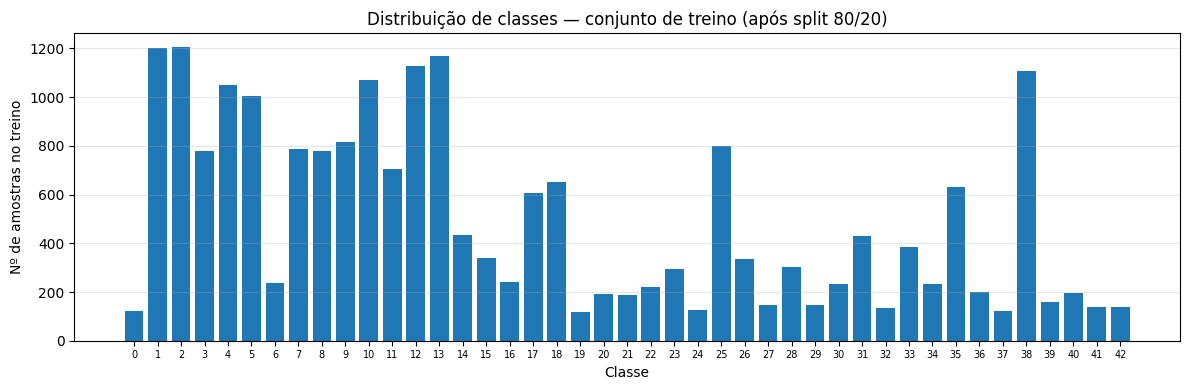

In [ ]:
train_subset = train_loader.dataset
train_indices = train_subset.indices
all_samples = train_subset.dataset._samples 
train_class_labels = np.array([all_samples[i][1] for i in train_indices])
train_class_counts = np.bincount(train_class_labels, minlength=NUM_CLASSES)

print(f"Classes com MENOS amostras no treino:")
for c in np.argsort(train_class_counts)[:5]:
    print(f"  Classe {c:2d}: {train_class_counts[c]:4d} amostras  ({GTSRB_CLASSES[c]})")
print(f"\nClasses com MAIS amostras no treino:")
for c in np.argsort(train_class_counts)[::-1][:5]:
    print(f"  Classe {c:2d}: {train_class_counts[c]:4d} amostras  ({GTSRB_CLASSES[c]})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(NUM_CLASSES), train_class_counts)
ax.set_xlabel("Classe")
ax.set_ylabel("Nº de amostras no treino")
ax.set_title("Distribuição de classes — conjunto de treino (após split 80/20)")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=7)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/baseline_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Modelo baseline

In [5]:
class BaselineCNN(nn.Module):
    """CNN baseline: 2 blocos conv (sem batch norm) + 2 camadas fully connected."""

    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BaselineCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)

Parâmetros treináveis: 1,079,275


## 4. Funções de treino e avaliação

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        preds = model(images).argmax(1).cpu().numpy()
        ps.append(preds)
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

## 5. Treinamento

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/baseline_best.pt")
        flag = "  <-- melhor val_acc"

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f}{flag}")

torch.save(model.state_dict(), "checkpoints/baseline_last.pt")
with open("checkpoints/baseline_history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"\nMelhor val_acc: {best_val_acc:.4f}")

train:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=3.5228 acc=0.0795 | val_loss=3.3756 acc=0.1070  <-- melhor val_acc


train:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 02/20 | train_loss=3.2815 acc=0.1418 | val_loss=3.1769 acc=0.1689  <-- melhor val_acc


train:   0%|          | 0/167 [00:00<?, ?it/s]

...

Epoch 18/20 | train_loss=0.2545 acc=0.9351 | val_loss=0.2308 acc=0.9439  <-- melhor val_acc


train:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.2124 acc=0.9467 | val_loss=0.2072 acc=0.9508  <-- melhor val_acc


train:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.1988 acc=0.9486 | val_loss=0.2620 acc=0.9189

Melhor val_acc: 0.9508


## 6. Curvas de treino

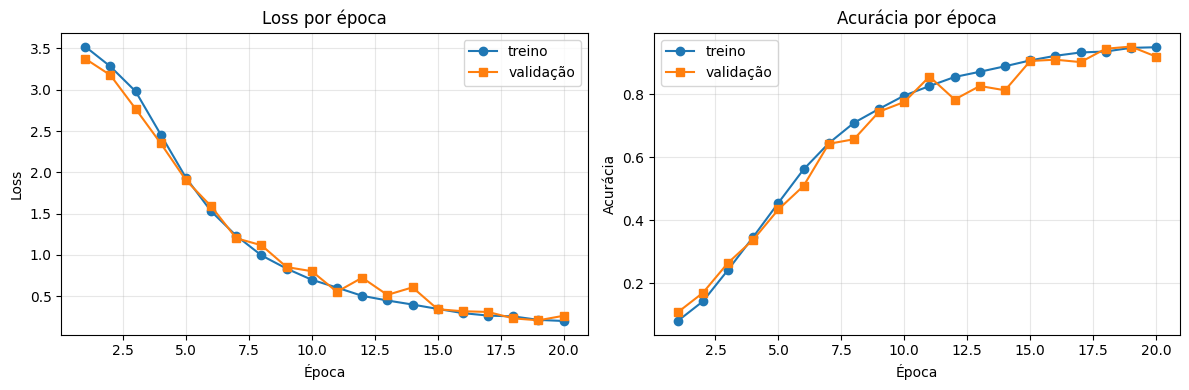

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], "o-", label="treino")
axes[0].plot(epochs, history["val_loss"], "s-", label="validação")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss por época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], "o-", label="treino")
axes[1].plot(epochs, history["val_acc"], "s-", label="validação")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia")
axes[1].set_title("Acurácia por época")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figs/baseline_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Avaliação no conjunto de teste

In [ ]:
model.load_state_dict(torch.load("checkpoints/baseline_best.pt", map_location=DEVICE))
model.eval()

y_true, y_pred = predict_all(model, test_loader, DEVICE)
assert y_pred.shape == (12630,), f"Esperado 12630 predições, obtido {y_pred.shape}"

global_acc = (y_pred == y_true).mean()
print(f"Acurácia global no teste: {global_acc:.4f}  ({(y_pred == y_true).sum()}/{len(y_true)})")

Acurácia global no teste: 0.7722  (9753/12630)


## 8. Métricas por classe

In [10]:
def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes)
    counts = np.zeros(num_classes, dtype=int)
    for c in range(num_classes):
        mask = y_true == c
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else 0.0
    return accs, counts

per_class_acc, per_class_count_test = per_class_accuracy(y_true, y_pred, NUM_CLASSES)
macro_acc = per_class_acc.mean()

print(f"Acurácia global : {global_acc:.4f}")
print(f"Macro accuracy  : {macro_acc:.4f}")
print(f"Pior classe     : {per_class_acc.argmin():2d}  acc={per_class_acc.min():.4f}  ({GTSRB_CLASSES[int(per_class_acc.argmin())]})")
print(f"Melhor classe   : {per_class_acc.argmax():2d}  acc={per_class_acc.max():.4f}  ({GTSRB_CLASSES[int(per_class_acc.argmax())]})")

Acurácia global : 0.7722
Macro accuracy  : 0.6947
Pior classe     :  0  acc=0.1500  (Speed limit (20km/h))
Melhor classe   : 13  acc=0.9806  (Yield)


### 8.1 Top 5 / bottom 5

In [11]:
sort_idx = np.argsort(per_class_acc)

print("=" * 90)
print("  5 classes com MAIOR acurácia")
print("=" * 90)
print(f"  {'cls':>3} | {'acc':>6} | {'n_test':>6} | {'n_treino':>8} | classe")
print("-" * 90)
for c in sort_idx[::-1][:5]:
    print(f"  {c:>3d} | {per_class_acc[c]:.4f} | {per_class_count_test[c]:>6d} | "
          f"{train_class_counts[c]:>8d} | {GTSRB_CLASSES[int(c)]}")

print()
print("=" * 90)
print("  5 classes com MENOR acurácia")
print("=" * 90)
print(f"  {'cls':>3} | {'acc':>6} | {'n_test':>6} | {'n_treino':>8} | classe")
print("-" * 90)
for c in sort_idx[:5]:
    print(f"  {c:>3d} | {per_class_acc[c]:.4f} | {per_class_count_test[c]:>6d} | "
          f"{train_class_counts[c]:>8d} | {GTSRB_CLASSES[int(c)]}")

  5 classes com MAIOR acurácia
  cls |    acc | n_test | n_treino | classe
------------------------------------------------------------------------------------------
   13 | 0.9806 |    720 |     1171 | Yield
   33 | 0.9667 |    210 |      384 | Turn right ahead
   35 | 0.9641 |    390 |      631 | Ahead only
   10 | 0.9591 |    660 |     1069 | No passing veh > 3.5t
   36 | 0.9500 |    120 |      201 | Go straight or right

  5 classes com MENOR acurácia
  cls |    acc | n_test | n_treino | classe
------------------------------------------------------------------------------------------
    0 | 0.1500 |     60 |      124 | Speed limit (20km/h)
   30 | 0.2733 |    150 |      232 | Beware of ice/snow
   27 | 0.3167 |     60 |      146 | Pedestrians
   24 | 0.3556 |     90 |      127 | Road narrows right
   21 | 0.4000 |     90 |      188 | Double curve


### 8.2 Acurácia por classe (gráfico completo)

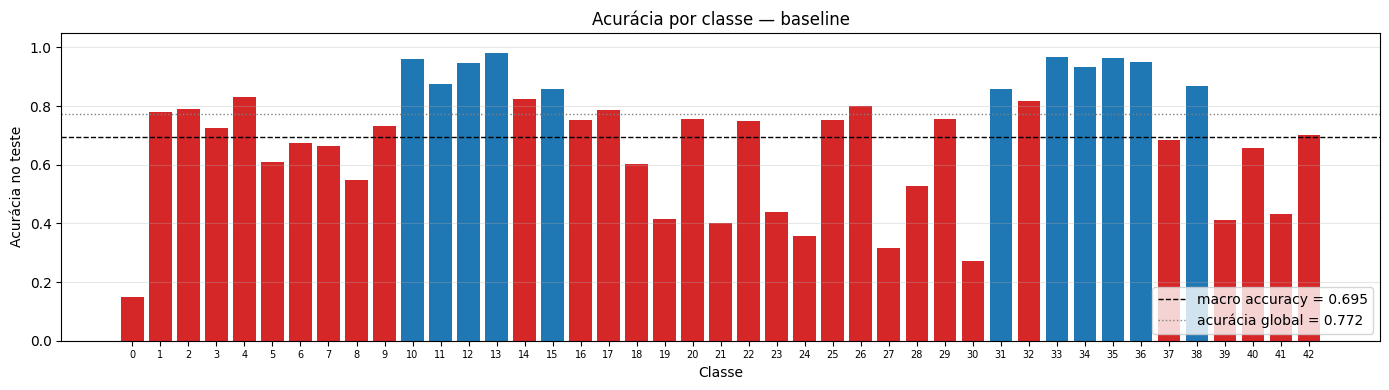

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ["tab:red" if a < 0.85 else "tab:blue" for a in per_class_acc]
ax.bar(range(NUM_CLASSES), per_class_acc, color=colors)
ax.axhline(macro_acc, color="black", linestyle="--", linewidth=1, label=f"macro accuracy = {macro_acc:.3f}")
ax.axhline(global_acc, color="gray", linestyle=":", linewidth=1, label=f"acurácia global = {global_acc:.3f}")
ax.set_xlabel("Classe")
ax.set_ylabel("Acurácia no teste")
ax.set_title("Acurácia por classe — baseline")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=7)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figs/baseline_per_class_acc.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Existe correlação entre frequência no treino e acurácia?

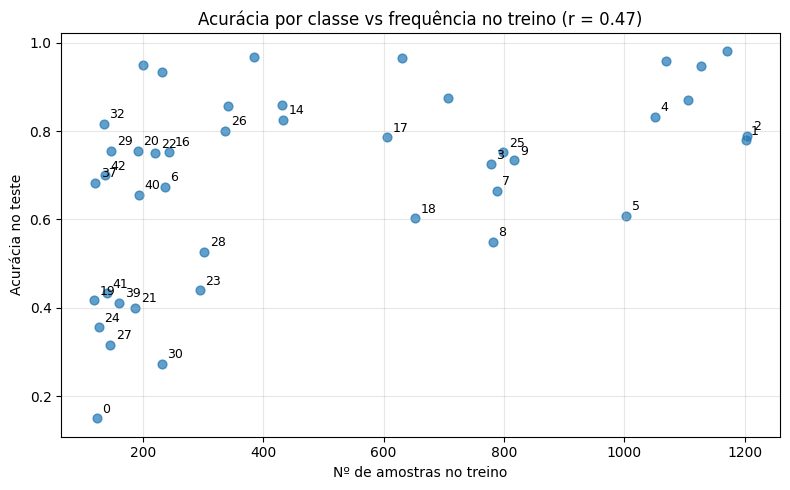

Correlação de Pearson entre frequência no treino e acurácia: r = 0.466


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train_class_counts, per_class_acc, s=40, alpha=0.7)

for c in range(NUM_CLASSES):
    if per_class_acc[c] < 0.85:
        ax.annotate(f"{c}", (train_class_counts[c], per_class_acc[c]),
                    fontsize=9, xytext=(4, 4), textcoords="offset points")

from numpy import corrcoef
r = corrcoef(train_class_counts, per_class_acc)[0, 1]

ax.set_xlabel("Nº de amostras no treino")
ax.set_ylabel("Acurácia no teste")
ax.set_title(f"Acurácia por classe vs frequência no treino (r = {r:.2f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/baseline_acc_vs_freq.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlação de Pearson entre frequência no treino e acurácia: r = {r:.3f}")

## 9. Matriz de confusão

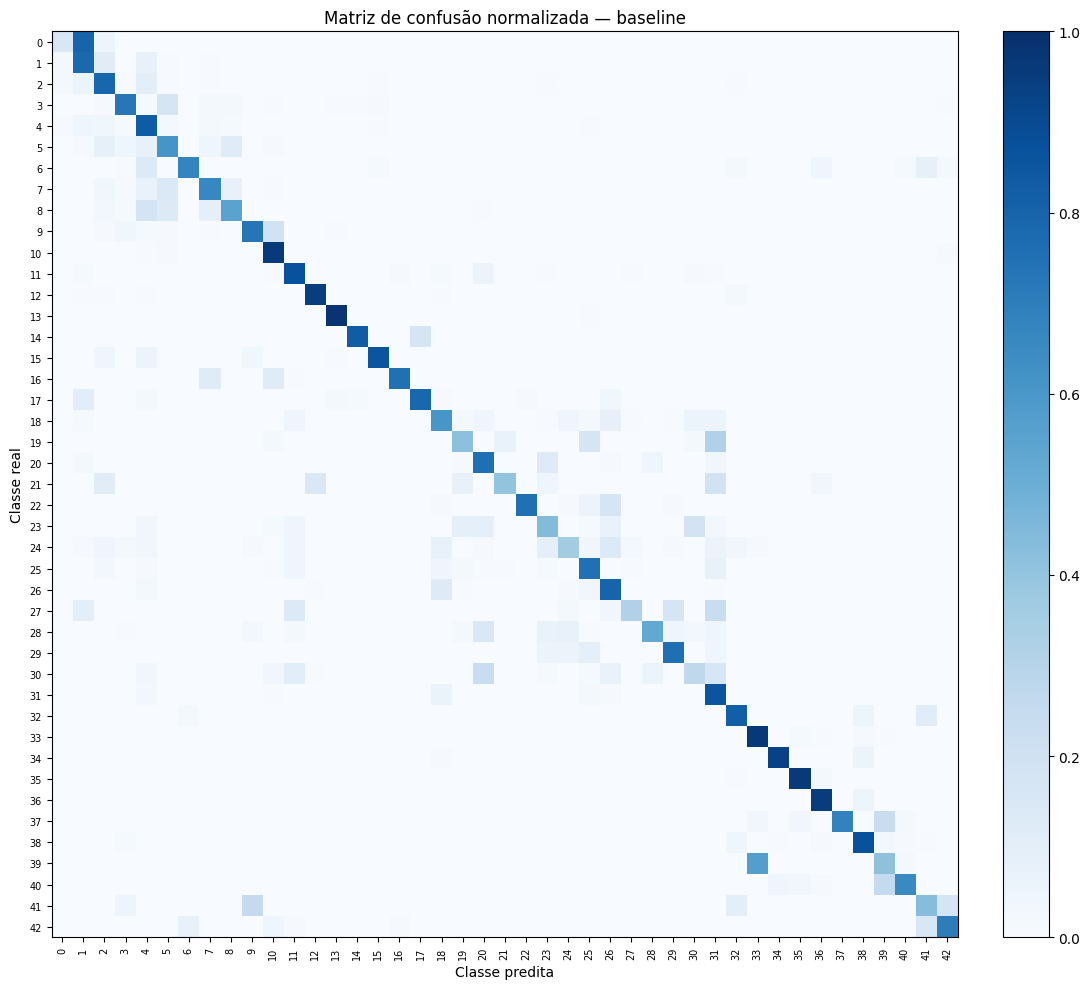

In [14]:
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

cm = confusion_matrix_np(y_true, y_pred, NUM_CLASSES)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")
ax.set_title("Matriz de confusão normalizada — baseline")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=7, rotation=90)
ax.set_yticklabels(range(NUM_CLASSES), fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("figs/baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.1 Pares mais confundidos

In [15]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

flat = np.argsort(cm_off.flatten())[::-1]
print("Top 10 pares mais confundidos (real → predito, contagem):")
print("-" * 90)
for k in range(10):
    i, j = np.unravel_index(flat[k], cm_off.shape)
    if cm_off[i, j] == 0:
        break
    print(f"  {cm_off[i, j]:>3d}x  {i:2d} ({GTSRB_CLASSES[int(i)]})")
    print(f"        → {j:2d} ({GTSRB_CLASSES[int(j)]})")

Top 10 pares mais confundidos (real → predito, contagem):
------------------------------------------------------------------------------------------
   90x   9 (No passing)
        → 10 (No passing veh > 3.5t)
   80x   8 (Speed limit (120km/h))
        →  4 (Speed limit (70km/h))
   79x   1 (Speed limit (30km/h))
        →  2 (Speed limit (50km/h))
   76x   3 (Speed limit (60km/h))
        →  5 (Speed limit (80km/h))
   76x   2 (Speed limit (50km/h))
        →  4 (Speed limit (70km/h))
   74x   5 (Speed limit (80km/h))
        →  8 (Speed limit (120km/h))
   63x   7 (Speed limit (100km/h))
        →  5 (Speed limit (80km/h))
   59x   8 (Speed limit (120km/h))
        →  5 (Speed limit (80km/h))
   54x   1 (Speed limit (30km/h))
        →  4 (Speed limit (70km/h))
   52x   5 (Speed limit (80km/h))
        →  2 (Speed limit (50km/h))


## 10. Exemplos visuais (acertos e erros)

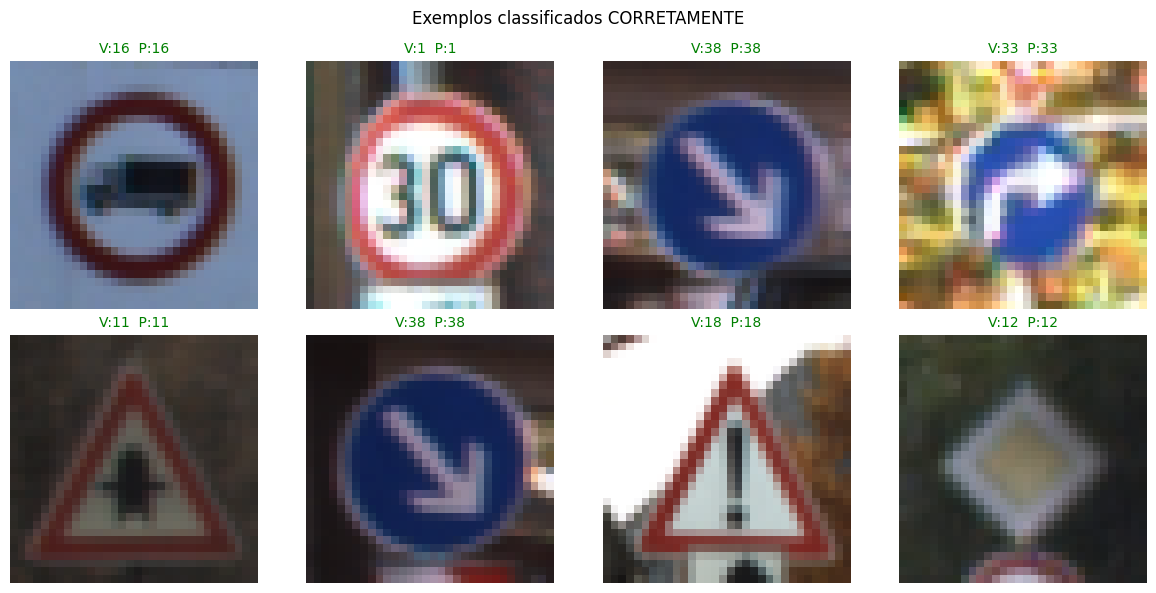

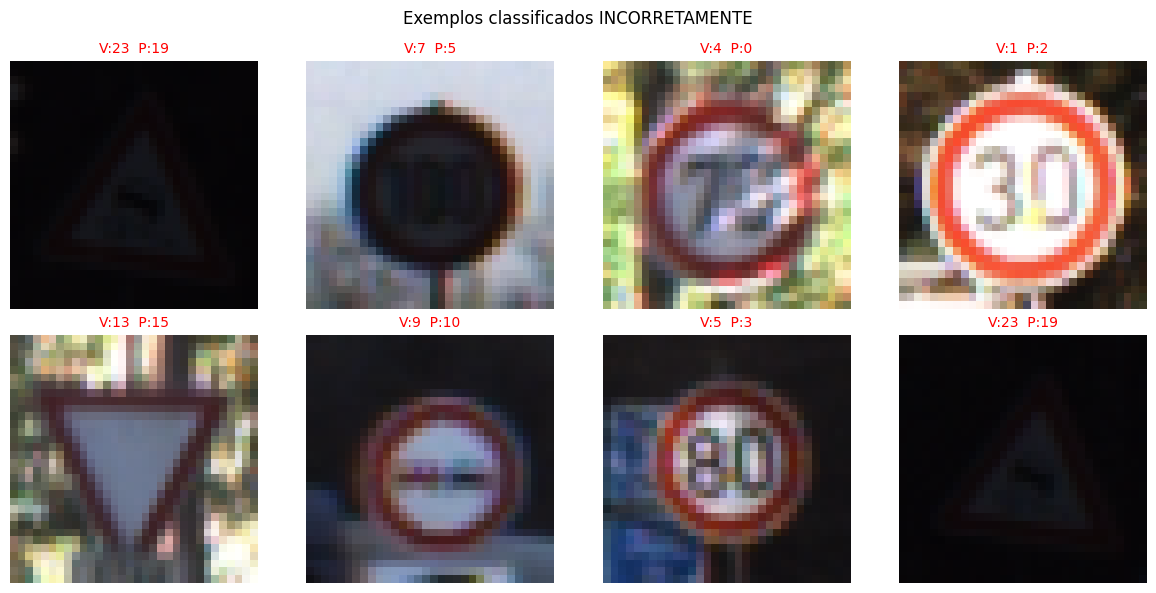

In [ ]:
MEAN = [0.3403, 0.3121, 0.3214]
STD = [0.2724, 0.2608, 0.2669]

def denormalize(img_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

test_iter = iter(test_loader)
images, labels = next(test_iter)
with torch.no_grad():
    preds = model(images.to(DEVICE)).argmax(1).cpu().numpy()
labels_np = labels.numpy()

correct_idx = np.where(preds == labels_np)[0][:8]
wrong_idx = np.where(preds != labels_np)[0][:8]

def show_grid(indices, title, fname):
    n = len(indices)
    if n == 0:
        print(f"({title}: nenhum exemplo encontrado neste batch)")
        return
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, idx in zip(axes, indices):
        img = denormalize(images[idx]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        t, p = int(labels_np[idx]), int(preds[idx])
        color = "green" if t == p else "red"
        ax.set_title(f"V:{t}  P:{p}", color=color, fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

show_grid(correct_idx, "Exemplos classificados CORRETAMENTE", "figs/baseline_correct.png")
show_grid(wrong_idx,   "Exemplos classificados INCORRETAMENTE", "figs/baseline_wrong.png")

## 11. Salvar predições no formato exigido

In [ ]:
save_predictions(
    y_pred,
    "results/predicoes_baseline.csv",
    experiment_name="Baseline CNN (2 conv + 2 fc) | SGD lr=0.01 | img=32 | 20 epochs",
)
print(f"CSV salvo: results/predicoes_baseline.csv  ({len(y_pred)} predições)")
print()

with open("results/predicoes_baseline.csv") as f:
    head = [next(f) for _ in range(5)]
print("Primeiras linhas do CSV:")
print("".join(head))

CSV salvo: results/predicoes_baseline.csv  (12630 predições)

Primeiras linhas do CSV:
# experiment: Baseline CNN (2 conv + 2 fc) | SGD lr=0.01 | img=32 | 20 epochs
image_index,predicted_class
0,16
1,1
2,38



## 12. Resumo do baseline e próximos passos